#  t-Test <hr style="border:2.5px solid #880909"></hr>

<b>Rica Galagate</b>
<br>3rd Year CpET Student</br>

In [1]:
# Import Packages
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.power import TTestPower
import os

In [2]:
# load dataset
df = pd.read_csv("CSV_files_Endterm_Project/googleplaystore.csv")
df

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10836,Sya9a Maroc - FR,FAMILY,4.5,38,53M,"5,000+",Free,0,Everyone,Education,"July 25, 2017",1.48,4.1 and up
10837,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,4,3.6M,100+,Free,0,Everyone,Education,"July 6, 2018",1.0,4.1 and up
10838,Parkinson Exercices FR,MEDICAL,NaN,3,9.5M,"1,000+",Free,0,Everyone,Medical,"January 20, 2017",1.0,2.2 and up
10839,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.5,114,Varies with device,"1,000+",Free,0,Mature 17+,Books & Reference,"January 19, 2015",Varies with device,Varies with device


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


In [4]:
df.describe()

,Rating
count,9367.000000
mean,4.193338
std,0.537431
min,1.000000
25%,4.000000
50%,4.300000
75%,4.500000
max,19.000000


## Data Cleaning

In [5]:
# convert Rating column into numeric values
df["Rating"] = pd.to_numeric(df["Rating"], errors="coerce")

# remove rows with missing ratings
df = df.dropna(subset=["Rating"])

# keep only Free and Paid apps
df = df[df["Type"].isin(["Free", "Paid"])]

df

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10834,FR Calculator,FAMILY,4.0,7,2.6M,500+,Free,0,Everyone,Education,"June 18, 2017",1.0.0,4.1 and up
10836,Sya9a Maroc - FR,FAMILY,4.5,38,53M,"5,000+",Free,0,Everyone,Education,"July 25, 2017",1.48,4.1 and up
10837,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,4,3.6M,100+,Free,0,Everyone,Education,"July 6, 2018",1.0,4.1 and up
10839,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.5,114,Varies with device,"1,000+",Free,0,Mature 17+,Books & Reference,"January 19, 2015",Varies with device,Varies with device


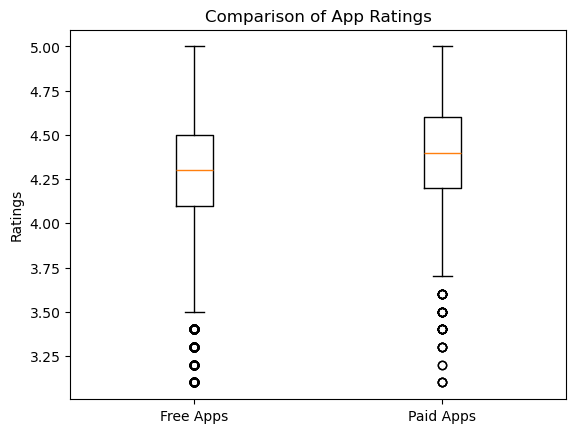

In [ ]:
# Boxplot
free_apps = df[df["Type"]=="Free"]["Rating"]
paid_apps = df[df["Type"]=="Paid"]["Rating"]

plt.boxplot([free_apps, paid_apps],
            tick_labels=["Free Apps","Paid Apps"])

plt.title("Comparison of App Ratings")
plt.ylabel("Ratings")
plt.show()

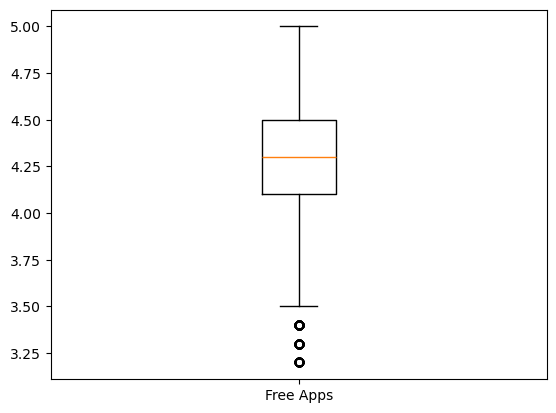

In [19]:
# Free Apps
free_apps = df[df['Type'] == 'Free']['Rating']
plt.boxplot(free_apps, tick_labels=['Free Apps'])
plt.show()

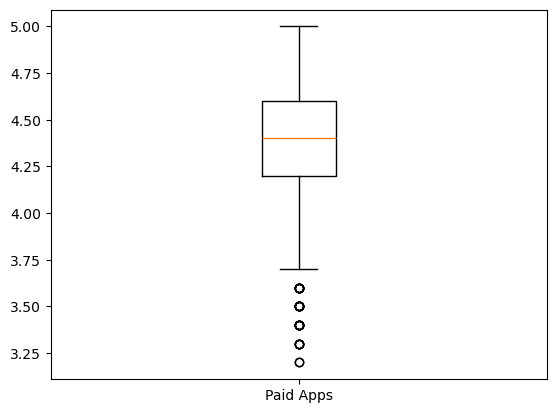

In [17]:
# Paid Apps
paid_apps = df[df['Type'] == 'Paid']['Rating']
plt.boxplot(paid_apps, tick_labels=['Paid Apps'])
plt.show()

In [18]:
# removing 3-sigma outliers
z_rating = stats.zscore(df['Rating'])
rating_outliers = (z_rating<-3)|(z_rating>3)
df = df[~rating_outliers]

In [ ]:
# save cleaned dataset
#df.to_csv(r"CSV_files_Endterm_Project\googleplaystore-cleaned.csv",
#            index=False)

In [21]:
# load dataset
df = pd.read_csv(r"CSV_files_Endterm_Project\googleplaystore-cleaned.csv",
                 delimiter=",")
df

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8922,FR Calculator,FAMILY,4.0,7,2.6M,500+,Free,0,Everyone,Education,"June 18, 2017",1.0.0,4.1 and up
8923,Sya9a Maroc - FR,FAMILY,4.5,38,53M,"5,000+",Free,0,Everyone,Education,"July 25, 2017",1.48,4.1 and up
8924,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,4,3.6M,100+,Free,0,Everyone,Education,"July 6, 2018",1.0,4.1 and up
8925,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.5,114,Varies with device,"1,000+",Free,0,Mature 17+,Books & Reference,"January 19, 2015",Varies with device,Varies with device


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8927 entries, 0 to 8926
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             8927 non-null   object 
 1   Category        8927 non-null   object 
 2   Rating          8927 non-null   float64
 3   Reviews         8927 non-null   int64  
 4   Size            8927 non-null   object 
 5   Installs        8927 non-null   object 
 6   Type            8927 non-null   object 
 7   Price           8927 non-null   object 
 8   Content Rating  8927 non-null   object 
 9   Genres          8927 non-null   object 
 10  Last Updated    8927 non-null   object 
 11  Current Ver     8923 non-null   object 
 12  Android Ver     8925 non-null   object 
dtypes: float64(1), int64(1), object(11)
memory usage: 906.8+ KB


In [23]:
df.describe()

,Rating,Reviews
count,8927.000000,8.927000e+03
mean,4.269721,5.392446e+05
std,0.367822,3.218325e+06
min,3.200000,1.000000e+00
25%,4.100000,2.430000e+02
50%,4.300000,7.690000e+03
75%,4.500000,9.150600e+04
max,5.000000,7.815831e+07


## 2 - Sample Test

## Free Apps and Paid Apps

In [58]:
df.groupby("Type")["Rating"].describe().T

Type,Free,Paid
count,8314.000000,613.000000
mean,4.263243,4.357586
std,0.366311,0.377204
min,3.200000,3.200000
25%,4.100000,4.200000
50%,4.300000,4.400000
75%,4.500000,4.600000
max,5.000000,5.000000


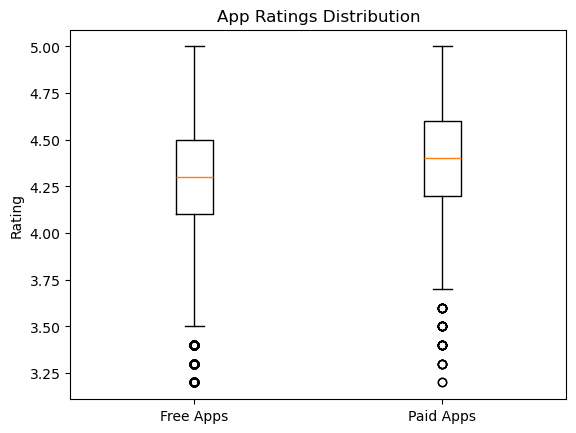

In [28]:
# Check for Outliers
plt.boxplot([free_apps, paid_apps],
            tick_labels=['Free Apps', 'Paid Apps'])

plt.title("App Ratings Distribution")
plt.ylabel("Rating")
plt.show()

In [59]:
# Shapiro-Wilk Normality Test
alpha = 0.05  

stats.shapiro(free_apps.sample(5000))

print("Free Apps Ratings")

w_stat, p_value = stats.shapiro(free_apps)

print(f"W-statistic: {w_stat:.4f}")
print(f"P-value: {p_value:.40f}")

# verdict
alpha = 0.05
if p_value < alpha:
    # reject null hypothesis
    print("Non-normal data")
else:
    # fail to reject null hypothesis
    print("Normal data")

stats.shapiro(paid_apps.sample(min(5000,len(paid_apps))))

print("\nPaid Apps Ratings")

w_stat, p_value = stats.shapiro(paid_apps)

print(f"W-statistic: {w_stat:.4f}")
print(f"P-value: {p_value:.15f}")

# verdict
alpha = 0.05
if p_value < alpha:
    # reject null hypothesis
    print("Non-normal data")
else:
    # fail to reject null hypothesis
    print("Normal data")

Free Apps Ratings
W-statistic: 0.9689
P-value: 0.0000000000000000000000000000000000000058
Non-normal data

Paid Apps Ratings
W-statistic: 0.9487
P-value: 0.000000000000097
Non-normal data


c:\Users\jhonm\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 8314.
  res = hypotest_fun_out(*samples, **kwds)


In [ ]:
"""
F-Test for equality of variances
--------------------------------
H0 : Variance of Free Apps = Variance of Paid Apps
H1 : Variance of Free Apps ≠ Variance of Paid Apps
"""

# compute variances
var_free = free_apps.var(ddof=1)
var_paid = paid_apps.var(ddof=1)

# compute F statistic
if var_free > var_paid:
    f_stat = var_free / var_paid
else:
    f_stat = var_paid / var_free

print(f"F-statistic: {f_stat:.4f}")

# degrees of freedom
dof_free = free_apps.count() - 1
dof_paid = paid_apps.count() - 1

# compute p-value
p_value = 1 - stats.f.cdf(f_stat, dof_free, dof_paid)

print(f"P-value: {p_value:.4f}")

# verdict
alpha = 0.05
if p_value < alpha:
    # reject null hypothesis
    print("unequal variances")
else:
    # fail to reject null hypothesis
    print("equal variances")

F-statistic: 1.0604
P-value: 0.1675
equal variances


In [52]:
"""
2- Sample T-Test for Independent Samples
----------------------------------------
H0 : Mean rating of Free Apps ≤ Mean rating of Paid Apps
H1 : Mean rating of Free Apps > Mean rating of Paid Apps
"""

# perform independent t-test
t_stat, p_value = stats.ttest_ind( free_apps,
                                   paid_apps,
                                   alternative="greater", 
                                   equal_var=True
)

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

alpha = 0.05

# verdict
if p_value < alpha:
    # reject null hypothesis
    print("Free apps have significantly higher ratings.")
else:
    # fail to reject null hypothesis
    print("No significant difference between ratings.")

T-statistic: -6.1411
P-value: 1.0000
No significant difference between ratings.


In [55]:
# Cohen's d
free_mean = free_apps.mean()
paid_mean = paid_apps.mean()
free_std = free_apps.std(ddof=1)

d = abs((free_mean - paid_mean) / free_std)

print(f"Cohen's d: {d:.4f}")

# Power of a Test
power = TTestPower().power( effect_size = -d,
                            nobs = free_apps.count(),
                            alpha = 0.05, alternative = "smaller" 
) 
print(f"Power of the test: {power*100:.2f}%")

Cohen's d: 0.2575
Power of the test: 100.00%
